# Discussion Group Week 4 - Exercise
In this notebook, you will be implementing a neural network using Pytorch. The goal is to create a simple feedforward neural network that can classify a synthetic dataset.

In [64]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torch import nn
import matplotlib.pyplot as plt

## Dataset
Below is the code to generate a synthetic dataset for classification. The dataset consists of five classes that are not linearly separable.

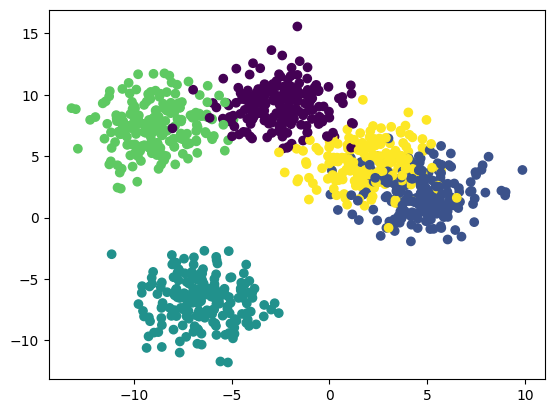

In [65]:
from sklearn.datasets import make_blobs

# Generate synthetic dataset with 5 classes
X, y = make_blobs(
    n_samples=1000,
    centers=5,        # number of labels/classes
    n_features=2,     # number of features (2 makes it easy to plot)
    cluster_std=1.7,  # spread of clusters
    random_state=42
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

## Pytorch Dataset

In [66]:
class CustomDataset(Dataset):
    def __init__(self, data, labels):
        self.data = torch.tensor(data, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]
    
dataset = CustomDataset(X, y)

## Pytorch Neural Network

In [67]:
class CustomNetwork(nn.Module):
    def __init__(self):
        super(CustomNetwork, self).__init__()
        self.layer1 = nn.Linear(2, 16)  # input layer to hidden layer
        self.layer2 = nn.Linear(16, 16)   # hidden layer to second hidden layer
        self.layer3 = nn.Linear(16, 5)   # hidden layer to output layer
        self.softmax = nn.Softmax(dim=1)  # softmax for multi-class classification

    def forward(self, x):
        x = self.layer1(x)
        x = nn.ReLU()(x)
        x = self.layer2(x)
        x = nn.ReLU()(x)
        x = self.layer3(x)
        x = self.softmax(x)
        return x

## Dataloader and Training Loop

In [68]:
batch_size = 32
learning_rate = 1e-3
num_epochs = 35

In [69]:
# Create dataset
dataset = CustomDataset(X, y)

# Randomly split the dataset into train, validation, test sets
train_set, val_set, test_set = random_split(dataset, [0.8, 0.1, 0.1])

# Create dataloaders from train, val, test sets
train_dataloader = DataLoader(train_set, batch_size, shuffle=True)
val_dataloader = DataLoader(val_set, batch_size, shuffle=True)
test_dataloader = DataLoader(test_set, batch_size, shuffle=True)

In [70]:
model = CustomNetwork()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)


In [71]:
# maintain history of train/val losses
train_losses = []
val_losses = []

for epoch in range(num_epochs):                                # In each epoch the entire training set is used for optimization 
    
    batch_loss = []
    for batch_X, batch_y in train_dataloader:                   # training set is batched
        
        y_pred = model(batch_X)                                 # predict y
        loss = criterion(y_pred, batch_y)                       # compute loss based on ground truth y and predict y 

        batch_loss.append(loss.item())

        optimizer.zero_grad()                                   # reset gradients to zero
        loss.backward()                                         # backpropagation
        optimizer.step()                                        # perform optimization step

    train_losses.append(sum(batch_loss) / len(batch_loss))
    
    with torch.no_grad():                                       # within this block, no gradients are computed

        batch_loss = []
        for batch_X, batch_y in val_dataloader:
            
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            batch_loss.append(loss.item())

        val_losses.append(sum(batch_loss) / len(batch_loss))

    print(f"{epoch=} \ttrain_loss = {train_losses[-1]:.4f}\tval_loss = {val_losses[-1]:.4f}")

epoch=0 	train_loss = 1.5380	val_loss = 1.4889
epoch=1 	train_loss = 1.4417	val_loss = 1.4194
epoch=2 	train_loss = 1.3460	val_loss = 1.3094
epoch=3 	train_loss = 1.2616	val_loss = 1.2649
epoch=4 	train_loss = 1.1984	val_loss = 1.1499
epoch=5 	train_loss = 1.1617	val_loss = 1.0871
epoch=6 	train_loss = 1.1392	val_loss = 1.0934
epoch=7 	train_loss = 1.1192	val_loss = 1.0554
epoch=8 	train_loss = 1.0979	val_loss = 1.0562
epoch=9 	train_loss = 1.0802	val_loss = 1.0414
epoch=10 	train_loss = 1.0647	val_loss = 1.0279
epoch=11 	train_loss = 1.0534	val_loss = 1.0421
epoch=12 	train_loss = 1.0453	val_loss = 1.0029
epoch=13 	train_loss = 1.0382	val_loss = 0.9978
epoch=14 	train_loss = 1.0332	val_loss = 1.0046
epoch=15 	train_loss = 1.0298	val_loss = 0.9931
epoch=16 	train_loss = 1.0264	val_loss = 1.0161
epoch=17 	train_loss = 1.0235	val_loss = 1.0293
epoch=18 	train_loss = 1.0205	val_loss = 0.9884
epoch=19 	train_loss = 1.0207	val_loss = 1.0294
epoch=20 	train_loss = 1.0168	val_loss = 0.9840
ep

## Visualize the results

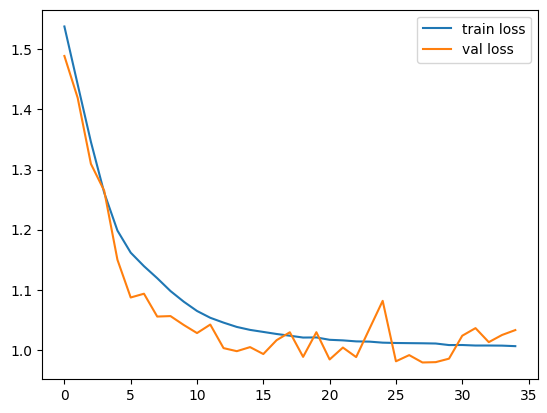

In [72]:
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.legend()
plt.show()

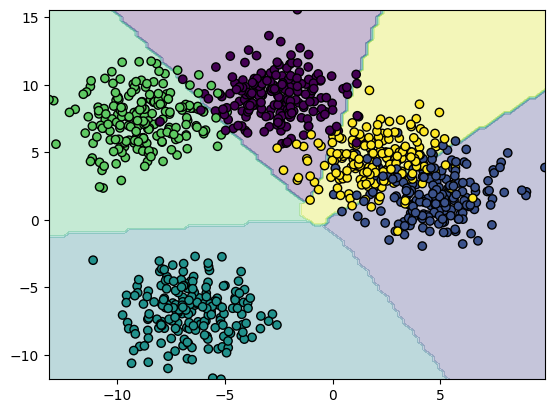

In [73]:
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min(), X[:, 0].max(), 100), 
    np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    )

grid = np.vstack([xx.flatten(), yy.flatten()]).T

predictions = model(torch.tensor(grid, dtype=torch.float32)).detach().numpy()
predicted_classes = np.argmax(predictions, axis=1)

plt.contourf(xx, yy, predicted_classes.reshape(xx.shape), alpha=0.3, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.show()


## Test metric

In [74]:
test_loss = 0

with torch.no_grad():

    for batch_X, batch_y in test_dataloader:
        
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        test_loss += loss.item()

test_loss / len(test_dataloader)

1.0208758264780045